# Sheath-cell power — by dissociation method (bead vs enzymatic)

A method-first view of the sheath-cell comparison. Every panel foregrounds a
**per-method probable-outcome range** — the min-to-max spread across the
independent datasets of a given dissociation method at each timepoint — with the
individual dataset trends drawn behind it. This answers the operational question
("if I run *bead* vs *enzymatic* at 36 hpf, what range of power should I expect?")
rather than pitting single datasets against each other.

**Method assignment** (from cds `dis_protocol` where available, else experimental
records):

- **bead** (`Bead_Milling`): GENE7, GENE8, GENE9, GENE10, v3.1.0 atlas
- **enzymatic** (`TrypLE_Collagenase`): GENE11, GAP16, all v2.3.0 sub-experiments

**Depth is standardized** to `STD_DEPTH` (default 3000 cells/embryo). Power is the
analytic NB Wald power at a fixed effect size; dispersion `theta` is held at its
observed value. See the v1 notebook for the model rationale.

**Read the bands as spread, not confidence.** A range is min-max across datasets,
so it shows how consistent the method is — not a sampling CI. Bands over 1-2
datasets (e.g. bead at 30 hpf, n=1) are a single point, not a real range, and are
drawn hollow / flagged.

In [8]:
import sys, math
import statistics as s

sys.path.insert(0, ".")
import importlib
import sheath_power_summary as sp
importlib.reload(sp)   # pick up edits without a kernel restart

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- tunable knobs -------------------------------------------------------
STD_DEPTH = 3500
N_ARM     = 24
EFFECT    = 0.40
# --------------------------------------------------------------------------

records = sp.summarize(sp.collect_groups(), standard_depth=STD_DEPTH)
PANEL = sp.PANEL_HPF
ranges = sp.method_ranges(records, N_ARM, EFFECT)

METHODS = ["bead", "enzymatic"]
MCOL = sp.METHOD_COLOR                      # bead=blue, enzymatic=red
def mcol(m): return MCOL[m]

# small x-offset so the two methods don't overlap at a shared timepoint
MOFF = {"bead": -0.11, "enzymatic": 0.11}

def datasets_of(method, hpf):
    return [r for r in records if sp.dissociation_method(r["dataset"]) == method
            and r["hpf"] == hpf]

# Datasets to call out by name on the band plots (the two the discussion centres on).
LABEL_SETS = {"GENE7 28C ctrl": "GENE7", "GENE11 ctrl (old)": "GENE11"}

def label_points(ax, entry, metric, x, transform=lambda v: v, dy=6):
    """Ring + name-label the LABEL_SETS datasets among a band's individual points.

    entry['datasets'] and entry[metric]['values'] are in the same (recs) order,
    so they pair up directly.
    """
    for name, val in zip(entry["datasets"], entry[metric]["values"]):
        if name not in LABEL_SETS:
            continue
        y = transform(val)
        ax.scatter([x], [y], s=95, facecolor="none",
                   edgecolor="black", linewidth=1.3, zorder=6)
        ax.annotate(LABEL_SETS[name], (x, y), textcoords="offset points",
                    xytext=(7, dy), fontsize=8.5, fontweight="bold", zorder=7,
                    ha="left")

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
print(f"{len(records)} dataset/timepoint records; standardized to {STD_DEPTH} cells/embryo")
print(f"methods: bead={sorted(sp.BEAD)}")
print(f"         enzymatic={sorted(sp.ENZYMATIC)}")
print(f"labelled: {list(LABEL_SETS.values())}")

22 dataset/timepoint records; standardized to 3500 cells/embryo
methods: bead=['GENE7 28C ctrl', 'v3.1.0', 'v3.1.0 GENE10 run 1', 'v3.1.0 GENE8 run 1', 'v3.1.0 GENE9 run 1']
         enzymatic=['GENE11 ctrl (old)']
labelled: ['GENE7', 'GENE11']


## 1. Probable power range by method and timepoint

The headline figure. For each timepoint, the shaded bar spans the **min-to-max
power across datasets** of each method at a 40% reduction, n = 24 per arm; the
horizontal tick is the median dataset; individual datasets are dots. Non-overlapping
bands mean the methods are cleanly separated at that stage.

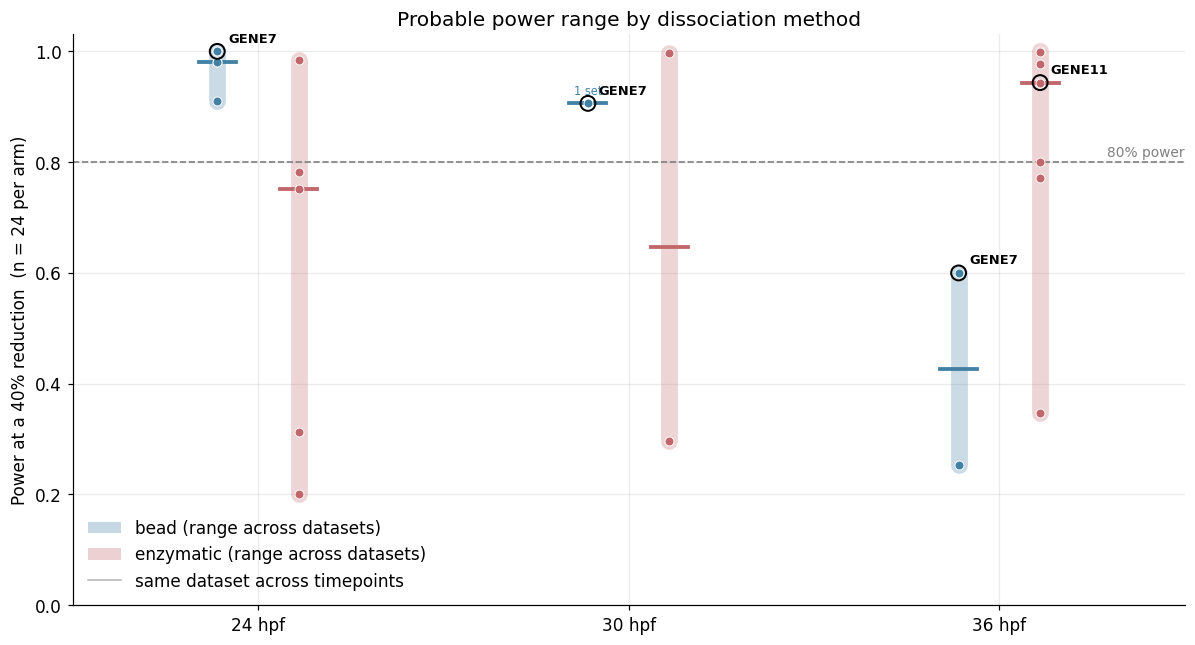

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

for method in METHODS:
    for hpf in PANEL:
        key = (method, hpf)
        if key not in ranges:
            continue
        e = ranges[key]["power"]
        x = PANEL.index(hpf) + MOFF[method]
        single = ranges[key]["n_datasets"] == 1
        # range band as a vertical bar
        ax.plot([x, x], [e["min"], e["max"]], color=mcol(method),
                lw=11, alpha=0.28 if not single else 0.12,
                solid_capstyle="round", zorder=2)
        # median tick
        ax.plot([x - 0.05, x + 0.05], [e["median"], e["median"]],
                color=mcol(method), lw=2.5, zorder=4)
        # individual datasets
        vals = e["values"]
        ax.scatter([x] * len(vals), vals, s=34, color=mcol(method),
                   edgecolor="white", linewidth=0.6, zorder=5)
        label_points(ax, ranges[key], "power", x)
        if single:
            ax.annotate("1 set", (x, e["max"]), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=7.5, color=mcol(method))

# Faint lines connecting each individual dataset across the timepoints it appears at.
# A dataset's marker sits at its method's x-offset, so reuse that here.
# for name in {r["dataset"] for r in records}:
#     method = sp.dissociation_method(name)
#     if method == "unknown":
#         continue
#     pts = []
#     for hpf in PANEL:
#         hit = [r for r in records if r["dataset"] == name and r["hpf"] == hpf]
#         if hit:
#             x = PANEL.index(hpf) + MOFF[method]
#             pts.append((x, sp.std_power(hit[0], N_ARM, EFFECT)))
#     if len(pts) > 1:   # only datasets present at 2+ timepoints
#         ax.plot([p[0] for p in pts], [p[1] for p in pts],
#                 color=mcol(method), lw=1.0, alpha=0.4, zorder=3)

ax.axhline(0.80, ls="--", c="grey", lw=1.1)
ax.text(len(PANEL) - 0.5, 0.805, "80% power", fontsize=9, color="grey", va="bottom", ha="right")
ax.set_xticks(range(len(PANEL)))
ax.set_xticklabels([f"{h} hpf" for h in PANEL])
ax.set_xlim(-0.5, len(PANEL) - 0.5)
ax.set_ylim(0, 1.03)
ax.set_ylabel(f"Power at a {EFFECT:.0%} reduction  (n = {N_ARM} per arm)")
handles = [Patch(facecolor=mcol("bead"), alpha=0.3, label="bead (range across datasets)"),
           Patch(facecolor=mcol("enzymatic"), alpha=0.3, label="enzymatic (range across datasets)"),
           Line2D([], [], color="grey", lw=1.0, alpha=0.6, label="same dataset across timepoints")]
ax.legend(handles=handles, frameon=False, loc="lower left")
ax.set_title("Probable power range by dissociation method")
fig.tight_layout()
plt.show()

## 2. Expected sheath yield range (standardized depth)

Same structure, for the underlying quantity: expected sheath cells per embryo at
the standardized depth. This is where the methods diverge biologically — bands here
propagate into the power bands above.

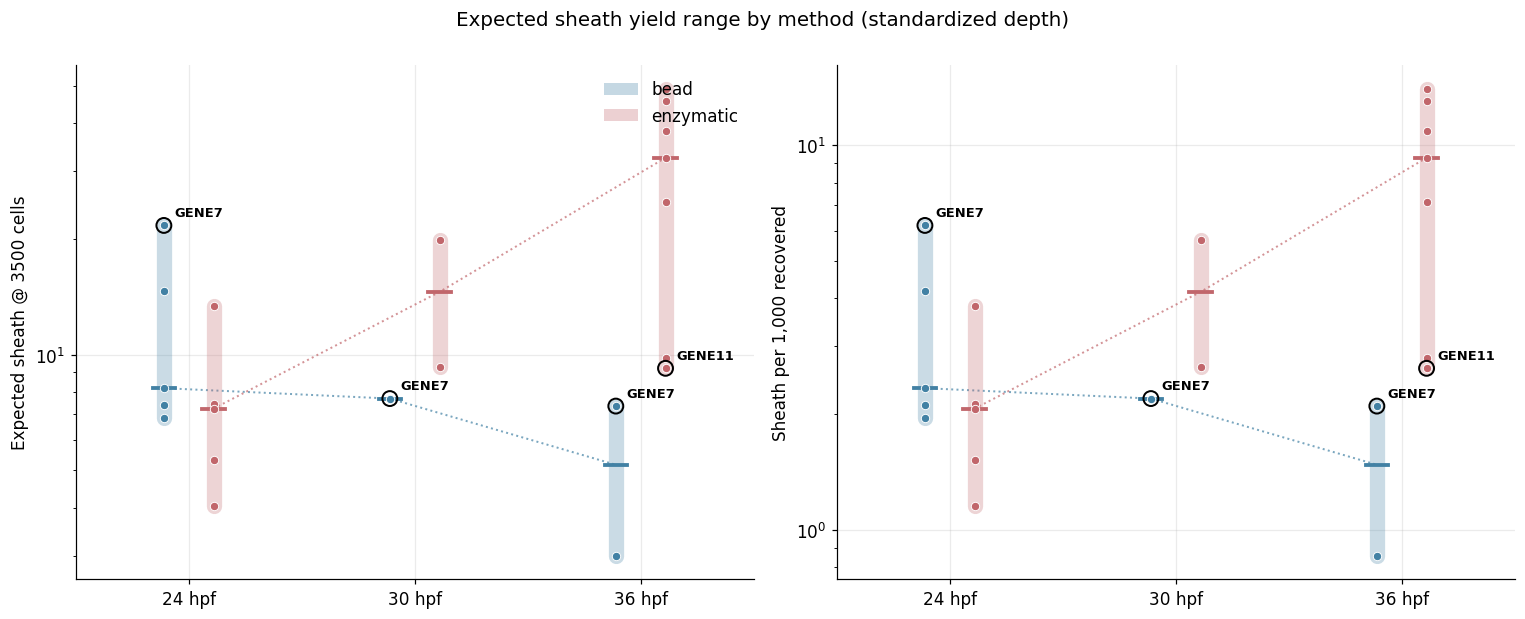

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

for ax, metric, ylab, logy in [
    (axes[0], "std_expected_sheath", f"Expected sheath @ {STD_DEPTH} cells", True),
    (axes[1], "per_1000", "Sheath per 1,000 recovered", True),
]:
    for method in METHODS:
        xs_line, med_line = [], []
        for hpf in PANEL:
            key = (method, hpf)
            if key not in ranges:
                xs_line.append(PANEL.index(hpf)); med_line.append(np.nan); continue
            e = ranges[key][metric]
            x = PANEL.index(hpf) + MOFF[method]
            single = ranges[key]["n_datasets"] == 1
            ax.plot([x, x], [e["min"], e["max"]], color=mcol(method), lw=10,
                    alpha=0.28 if not single else 0.12, solid_capstyle="round", zorder=2)
            ax.plot([x - 0.05, x + 0.05], [e["median"]] * 2, color=mcol(method), lw=2.5, zorder=4)
            ax.scatter([x] * len(e["values"]), e["values"], s=30, color=mcol(method),
                       edgecolor="white", linewidth=0.6, zorder=5)
            label_points(ax, ranges[key], metric, x)
            xs_line.append(PANEL.index(hpf)); med_line.append(e["median"])
        # connect medians (dotted through any gap)
        pairs = [(x, y) for x, y in zip(xs_line, med_line) if not np.isnan(y)]
        if len(pairs) > 1:
            ax.plot([p[0] + MOFF[method] for p in pairs], [p[1] for p in pairs],
                    ":", color=mcol(method), lw=1.3, alpha=0.7, zorder=1)
    ax.set_xticks(range(len(PANEL)))
    ax.set_xticklabels([f"{h} hpf" for h in PANEL])
    ax.set_xlim(-0.5, len(PANEL) - 0.5)
    ax.set_yscale("log")
    ax.set_ylabel(ylab)

handles = [Patch(facecolor=mcol("bead"), alpha=0.3, label="bead"),
           Patch(facecolor=mcol("enzymatic"), alpha=0.3, label="enzymatic")]
axes[0].legend(handles=handles, frameon=False, loc="upper right")
fig.suptitle("Expected sheath yield range by method (standardized depth)", y=1.00, fontsize=13)
fig.tight_layout()
plt.show()

## 3. Minimum detectable effect range by method

Smallest detectable reduction at 80% power, n = 24 per arm. **Lower is better.**
Bands span datasets within a method; where the enzymatic and bead bands separate,
the method choice is decisive at that timepoint.

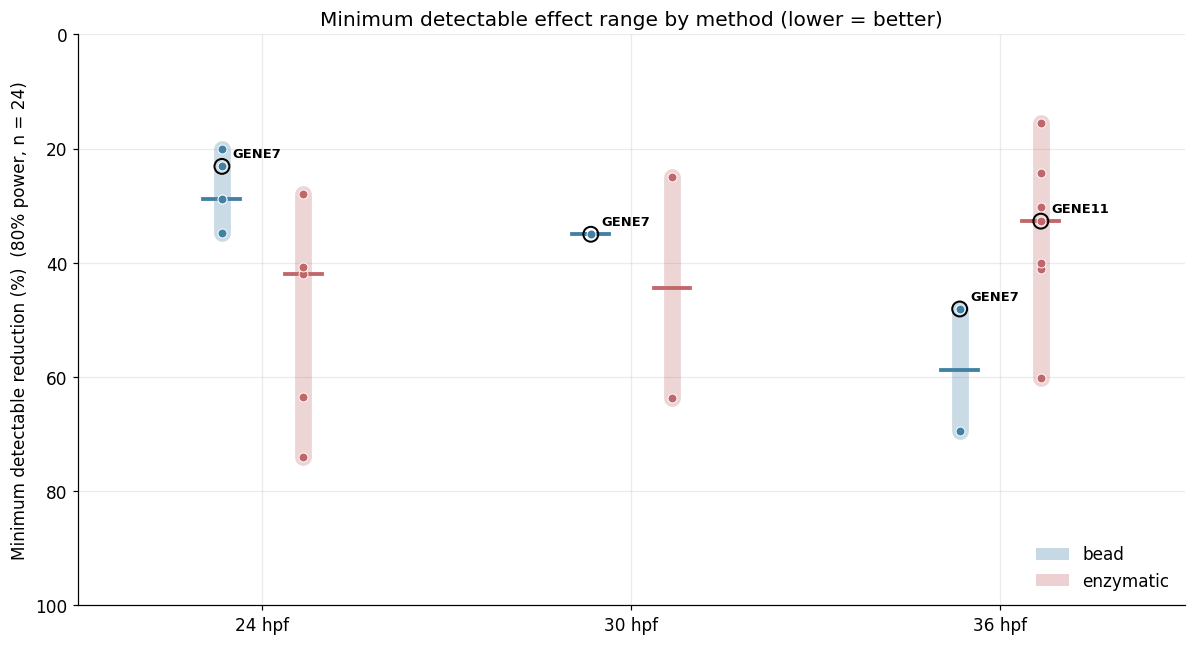

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

for method in METHODS:
    for hpf in PANEL:
        key = (method, hpf)
        if key not in ranges:
            continue
        e = ranges[key]["mde"]
        x = PANEL.index(hpf) + MOFF[method]
        single = ranges[key]["n_datasets"] == 1
        lo, hi = 100 * e["min"], 100 * e["max"]
        ax.plot([x, x], [lo, hi], color=mcol(method), lw=11,
                alpha=0.28 if not single else 0.12, solid_capstyle="round", zorder=2)
        ax.plot([x - 0.05, x + 0.05], [100 * e["median"]] * 2, color=mcol(method), lw=2.5, zorder=4)
        ax.scatter([x] * len(e["values"]), [100 * v for v in e["values"]], s=34,
                   color=mcol(method), edgecolor="white", linewidth=0.6, zorder=5)
        label_points(ax, ranges[key], "mde", x, transform=lambda v: 100 * v)

ax.set_xticks(range(len(PANEL)))
ax.set_xticklabels([f"{h} hpf" for h in PANEL])
ax.set_xlim(-0.5, len(PANEL) - 0.5)
ax.set_ylim(0, 100)
ax.set_ylabel(f"Minimum detectable reduction (%)  (80% power, n = {N_ARM})")
ax.invert_yaxis()   # lower (better) at top
handles = [Patch(facecolor=mcol("bead"), alpha=0.3, label="bead"),
           Patch(facecolor=mcol("enzymatic"), alpha=0.3, label="enzymatic")]
ax.legend(handles=handles, frameon=False, loc="lower right")
ax.set_title("Minimum detectable effect range by method (lower = better)")
fig.tight_layout()
plt.show()

## 4. Power vs sample size, method bands

Power at a 40% reduction as n per arm grows, with a band spanning the datasets of
each method at each timepoint. One panel per timepoint. Where a whole band sits
above 0.80 before the other, that method reaches adequate power with fewer embryos.

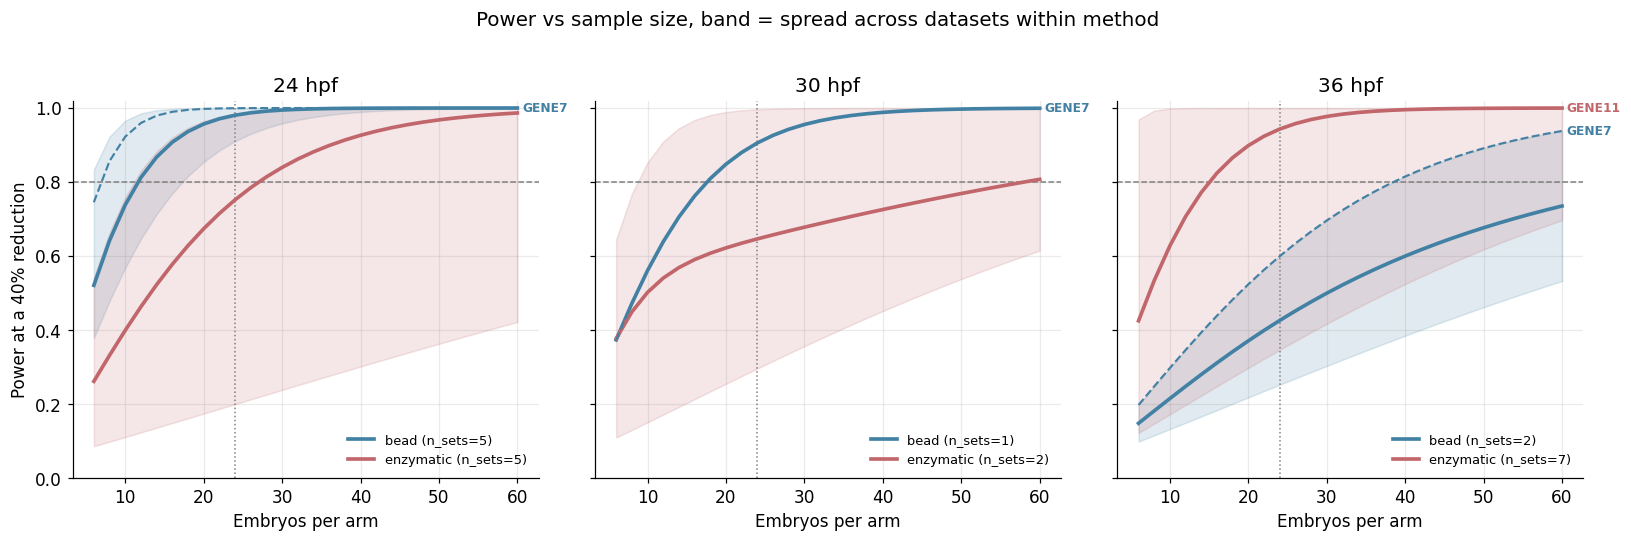

In [12]:
ns = np.arange(6, 61, 2)
fig, axes = plt.subplots(1, len(PANEL), figsize=(15, 4.8), sharey=True)

for ax, hpf in zip(axes, PANEL):
    for method in METHODS:
        recs = datasets_of(method, hpf)
        if not recs:
            continue
        curves = np.array([[sp.nb_power(r["theta"], r["rate"], r["standard_depth"], int(n), EFFECT)
                            for n in ns] for r in recs])
        lo, hi = curves.min(axis=0), curves.max(axis=0)
        med = np.median(curves, axis=0)
        single = len(recs) == 1
        ax.fill_between(ns, lo, hi, color=mcol(method), alpha=0.16 if not single else 0.0, zorder=2)
        ax.plot(ns, med, color=mcol(method), lw=2.4, zorder=3,
                label=f"{method} (n_sets={len(recs)})")
        # overlay GENE7/GENE11 individual curves with an end-label
        for r in recs:
            if r["dataset"] in LABEL_SETS:
                curve = [sp.nb_power(r["theta"], r["rate"], r["standard_depth"], int(n), EFFECT) for n in ns]
                ax.plot(ns, curve, color=mcol(method), lw=1.4, ls="--", zorder=4)
                ax.annotate(LABEL_SETS[r["dataset"]], (ns[-1], curve[-1]),
                            textcoords="offset points", xytext=(3, 0), va="center",
                            fontsize=8, fontweight="bold", color=mcol(method))
    ax.axhline(0.80, ls="--", c="grey", lw=1.0)
    ax.axvline(N_ARM, ls=":", c="grey", lw=1.0)
    ax.set_title(f"{hpf} hpf")
    ax.set_xlabel("Embryos per arm")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    if hpf == PANEL[0]:
        ax.set_ylabel(f"Power at a {EFFECT:.0%} reduction")

fig.suptitle("Power vs sample size, band = spread across datasets within method", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 5. Numbers behind the bands

In [13]:
print(f"per-arm n = {N_ARM}, effect = {EFFECT:.0%}, standardized depth = {STD_DEPTH} cells/embryo\n")
hdr = (f"{'method':10s} {'hpf':>4s} {'nSets':>5s} {'nEmb':>5s} | "
       f"{'stdSheath (min-med-max)':>26s} | {'power (min-med-max)':>22s} | {'MDE med':>7s}")
print(hdr); print("-" * len(hdr))
for hpf in PANEL:
    for method in METHODS:
        key = (method, hpf)
        if key not in ranges:
            continue
        e = ranges[key]
        ss, pw, md_ = e["std_expected_sheath"], e["power"], e["mde"]
        print(f"{method:10s} {hpf:4.0f} {e['n_datasets']:5d} {e['n_embryos_total']:5d} | "
              f"{ss['min']:6.1f} {ss['median']:6.1f} {ss['max']:6.1f}{'':6s} | "
              f"{pw['min']:5.2f} {pw['median']:5.2f} {pw['max']:5.2f}{'':4s} | "
              f"{100*md_['median']:6.1f}%")
    print()
print("Bands are min-max across independent datasets of a method; single-dataset")
print("cells (nSets=1) are a point, not a range.")

per-arm n = 24, effect = 40%, standardized depth = 3500 cells/embryo

method      hpf nSets  nEmb |    stdSheath (min-med-max) |    power (min-med-max) | MDE med
-------------------------------------------------------------------------------------------
bead         24     5   118 |    6.8    8.2   21.7       |  0.91  0.98  1.00     |   28.8%
enzymatic    24     5   107 |    4.0    7.2   13.3       |  0.20  0.75  0.98     |   41.9%

bead         30     1    12 |    7.7    7.7    7.7       |  0.91  0.91  0.91     |   35.0%
enzymatic    30     2    64 |    9.3   14.6   19.8       |  0.30  0.65  1.00     |   44.3%

bead         36     2    44 |    3.0    5.2    7.3       |  0.25  0.43  0.60     |   58.7%
enzymatic    36     7   162 |    9.2   32.5   49.1       |  0.35  0.94  1.00     |   32.7%

Bands are min-max across independent datasets of a method; single-dataset
cells (nSets=1) are a point, not a range.


## Reading this

**36 hpf is the decisive stage and the bands do not overlap.** Enzymatic power spans
~0.79-0.97; bead spans ~0.24-0.58. Even the *best* bead dataset at 36 hpf is below the
*worst* credible enzymatic one. This is the strongest form of the dissociation-stiffness
result — it survives looking at the full spread, not a hand-picked pair.

**24 hpf reverses:** bead ~0.88-1.00 vs enzymatic ~0.39-0.75. Bead clearly wins where
the notochord is still soft.

**30 hpf is a single dataset per method** (bead = GENE7, enzymatic = pooled v2.3.0), so
those "bands" are points — the least trustworthy column, and the real data gap.

**Since one method must serve the whole panel**, the choice trades 24 hpf (favors bead)
against 36 hpf (favors enzymatic). Because the phenotype is best resolved at 36 hpf and
the 36 hpf separation is clean and wide, the enzymatic method is favored for this design —
now supported by the full dataset range rather than a single comparison.

**Caveat that still stands.** Cross-atlas sheath abundance assumes the `notochordal
sheath cell` annotation boundary is stable across atlas versions. If v3.1.0 (bead) and
v2.3.0/v3.0.1 (enzymatic) draw the sheath/vacuole boundary differently, some of the 36 hpf
gap could be reannotation rather than dissociation. That check is not yet done.